In [3]:
import pandas as pd

data = pd.read_csv('Amazon_Reviews.csv')
print(data.columns)
print(data.head())

Index(['Reviewer Name', 'Profile Link', 'Country', 'Review Count',
       'Review Date', 'Rating', 'Review Title', 'Review Text',
       'Date of Experience'],
      dtype='object')
      Reviewer Name                     Profile Link Country Review Count  \
0        Eugene ath  /users/66e8185ff1598352d6b3701a      US     1 review   
1  Daniel ohalloran  /users/5d75e460200c1f6a6373648c      GB    9 reviews   
2          p fisher  /users/546cfcf1000064000197b88f      GB   90 reviews   
3         Greg Dunn  /users/62c35cdbacc0ea0012ccaffa      AU    5 reviews   
4     Sheila Hannah  /users/5ddbe429478d88251550610e      GB    8 reviews   

                Review Date                  Rating  \
0  2024-09-16T13:44:26.000Z  Rated 1 out of 5 stars   
1  2024-09-16T18:26:46.000Z  Rated 1 out of 5 stars   
2  2024-09-16T21:47:39.000Z  Rated 1 out of 5 stars   
3  2024-09-17T07:15:49.000Z  Rated 1 out of 5 stars   
4  2024-09-16T18:37:17.000Z  Rated 1 out of 5 stars   

                        

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Original Shape: (21214, 9)
Processed Shape: (20170, 3)

Accuracy: 0.9313336638572137

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.95      2870
           1       0.92      0.84      0.88      1164

    accuracy                           0.93      4034
   macro avg       0.93      0.90      0.91      4034
weighted avg       0.93      0.93      0.93      4034



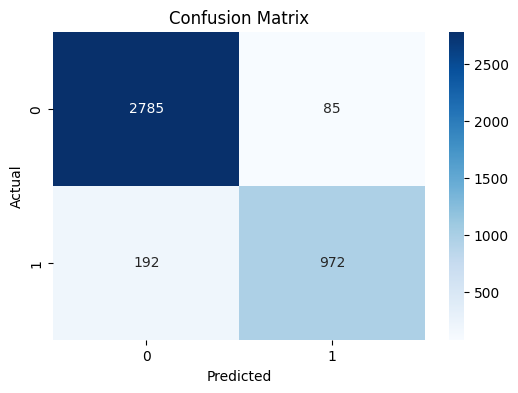

In [7]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

nltk.download('stopwords')

# -----------------------------------
# 1️⃣ Load Dataset (Safe Method)
# -----------------------------------
data = pd.read_csv('Amazon_Reviews.csv', engine='python')

print("Original Shape:", data.shape)

# -----------------------------------
# 2️⃣ Keep Required Columns
# -----------------------------------
data = data[['Review Text', 'Rating']]

# Drop rows with missing review text
data = data.dropna(subset=['Review Text'])

# -----------------------------------
# 3️⃣ Extract Numeric Rating Safely
# -----------------------------------
data['Rating'] = data['Rating'].astype(str).str.extract(r'(\d)')

# Remove rows where rating extraction failed
data = data.dropna(subset=['Rating'])

# Convert to integer
data['Rating'] = data['Rating'].astype(int)

# Remove neutral (3-star)
data = data[data['Rating'] != 3]

# Create Sentiment Column
data['sentiment'] = data['Rating'].apply(lambda x: 1 if x >= 4 else 0)

print("Processed Shape:", data.shape)

# -----------------------------------
# 4️⃣ Clean Text
# -----------------------------------
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    return text

data['Review Text'] = data['Review Text'].apply(clean_text)

# -----------------------------------
# 5️⃣ Remove Stopwords
# -----------------------------------
stop_words = set(stopwords.words('english'))

data['Review Text'] = data['Review Text'].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop_words])
)

# -----------------------------------
# 6️⃣ Train-Test Split
# -----------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    data['Review Text'],
    data['sentiment'],
    test_size=0.2,
    random_state=42
)

# -----------------------------------
# 7️⃣ TF-IDF Vectorization
# -----------------------------------
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# -----------------------------------
# 8️⃣ Model Training
# -----------------------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# -----------------------------------
# 9️⃣ Predictions
# -----------------------------------
y_pred = model.predict(X_test_tfidf)

# -----------------------------------
# 🔟 Evaluation
# -----------------------------------
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()